<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12256906 entries, 0 to 12256905
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        int64 
 1   item_id        int64 
 2   behavior_type  int64 
 3   user_geohash   object
 4   item_category  int64 
 5   time           object
dtypes: int64(4), object(2)
memory usage: 561.1+ MB
None
    user_id    item_id  behavior_type user_geohash  item_category  \
0  98047837  232431562              1          NaN           4245   
1  97726136  383583590              1          NaN           5894   
2  98607707   64749712              1          NaN           2883   
3  98662432  320593836              1      96nn52n           6562   
4  98145908  290208520              1          NaN          13926   

            time  
0  2014-12-06 02  
1  2014-12-09 20  
2  2014-12-18 11  
3  2014-12-06 10  
4  2014-12-16 21  
    user_id    item_id  behavior_type  item_category                time  \
0  98047

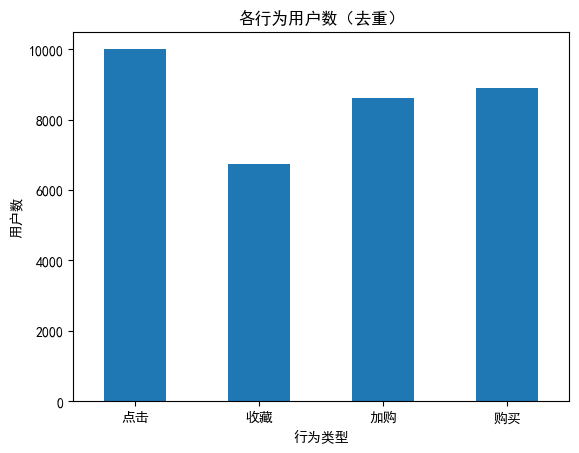

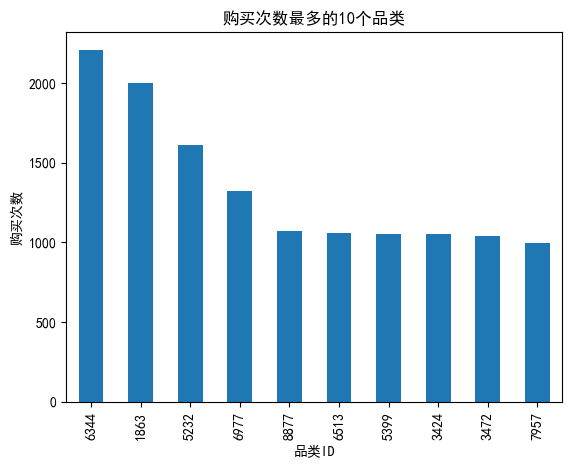

user_type
多次购买    84.121089
单次购买     8.305199
两次购买     7.573711
Name: proportion, dtype: float64


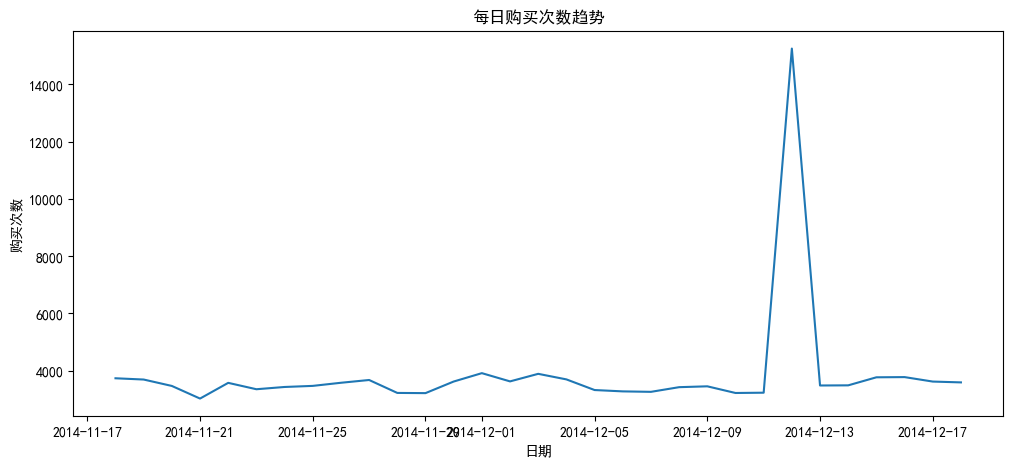

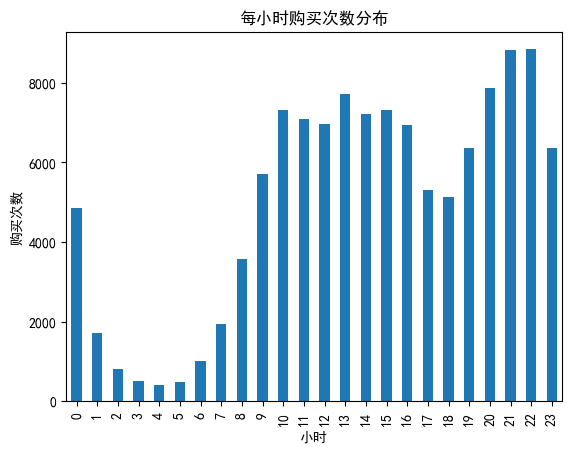

In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\chen\Downloads\csv\.csv")
print(df.info())
print(df.head())
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H')
df['date']=df['time'].dt.date
df['hour']=df['time'].dt.hour
df.drop('user_geohash',axis=1,inplace=True)
print(df.head())
print(df.isnull().sum())
behavior_counts = df.groupby('behavior_type')['user_id'].nunique()
print(behavior_counts)
behavior_total = df['behavior_type'].value_counts().sort_index()
print(behavior_total)
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
behavior_counts.plot(kind='bar')
plt.title('各行为用户数（去重）')
plt.xlabel('行为类型')
plt.ylabel('用户数')
plt.xticks(ticks=[0,1,2,3], labels=['点击', '收藏', '加购', '购买'], rotation=0)
plt.show()
buy_df = df[df['behavior_type'] == 4]
# 统计各品类的购买次数
category_buy = buy_df['item_category'].value_counts().head(10)
category_buy.plot(kind='bar')
plt.title('购买次数最多的10个品类')
plt.xlabel('品类ID')
plt.ylabel('购买次数')
plt.show()
# 每个用户的购买次数（按用户统计）
user_buy_counts = buy_df.groupby('user_id')['behavior_type'].count()
# 划分用户类型
def user_type(count):
    if count == 1:
        return '单次购买'
    elif count == 2:
        return '两次购买'
    else:
        return '多次购买'
user_buy_counts = user_buy_counts.reset_index(name='buy_count')
user_buy_counts['user_type'] = user_buy_counts['buy_count'].apply(user_type)
# 统计各类用户占比
user_type_dist = user_buy_counts['user_type'].value_counts(normalize=True) * 100
print(user_type_dist)
# 按天统计购买次数
daily_buy = buy_df.groupby('date').size()
daily_buy.plot(figsize=(12,5))
plt.title('每日购买次数趋势')
plt.xlabel('日期')
plt.ylabel('购买次数')
plt.show()
# 按小时统计购买次数
hourly_buy = buy_df.groupby('hour').size()
hourly_buy.plot(kind='bar')
plt.title('每小时购买次数分布')
plt.xlabel('小时')
plt.ylabel('购买次数')
plt.show()